In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys


def get_dir_n_levels_up(path, n):
    # Go up n levels from the given path
    for _ in range(n):
        path = os.path.dirname(path)
    return path


proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
sys.path.append(proj_root)

print(proj_root)

import numpy as np
import matplotlib.pyplot as plt

from opinion_dynamics.identify import run_paper_baseline_like, v_from_P
from opinion_dynamics.utils.env_setup import EnvironmentFactory

from opinion_dynamics.identify import GraphIdentifierEnv, train_graph_identifier, pairs_from_intermediate
from opinion_dynamics.baseline import centrality_based_continuous_control

from rl_envs_forge.envs.network_graph.graph_utils import compute_laplacian, compute_eigenvector_centrality


d:\Work\repos\RL\unknown_graph_networks


In [3]:


env_factory = EnvironmentFactory()
env = env_factory.get_randomized_env()

In [4]:
# out = run_paper_baseline_like(
#     env,
#     B_total=1.0,
#     num_campaigns=5,
#     lr=1e-3,
#     diag_penalty=1.0,
#     l2_lambda=0.0,
#     device="cpu",
#     learn_first_without_control=True,
# )

# print("=== Trial run complete ===")
# print("states:", out["states"].shape)
# print("actions:", out["actions"].shape)
# print("A_hats:", len(out["A_hats"]))

# if out["A_hats"]:
#     A0 = out["A_hats"][0]
#     print("A_hat[0] row-sum min/max:", A0.sum(axis=1).min(), A0.sum(axis=1).max())

# # optional plot
# try:
#     env.render(mode="centralities")
# except Exception as e:
#     print("[render skipped]", e)

In [5]:
def run_single_paper_experiment(
    *,
    B_total: float = 1.0,
    num_campaigns_total: int = 5,     # total campaigns including the initial zero-control one
    lr: float = 1e-3,
    diag_penalty: float = 1.0,
    l2_lambda: float = 0.0,
    device: str = "cpu",
    update_A_each_campaign: bool = True,  # paper updates online; keep True
):
    env_factory = EnvironmentFactory()
    env = env_factory.get_randomized_env()
    
    N = env.num_agents
    ubar_vec = np.asarray(env.max_u, dtype=float)

    # --- storage ---
    states = []
    actions = []
    rewards = []
    A_hats = []
    v_hats = []
    
    # data buffers for learning (x_l, x_{l+1})
    buf_x, buf_y = [], []

    # reset env
    x, info = env.reset()
    states.append(x.copy())

    # --- Campaign 0: NO CONTROL (paper-style initial observation window) ---
    u0 = np.zeros(N, dtype=float)
    x1, r0, done, trunc, info0 = env.step(u0)
    actions.append(u0.copy())
    rewards.append(float(r0))
    states.append(x1.copy())

    inter0 = info0.get("intermediate_states", None)
    if inter0 is None:
        raise RuntimeError("env.step did not return info['intermediate_states']; cannot fit A_hat.")
    Xp, Yp = pairs_from_intermediate(inter0)
    buf_x.append(Xp)
    buf_y.append(Yp)

    # init learner
    gi = GraphIdentifierEnv(N=N, s=env.t_s, l2_lambda=l2_lambda, zero_diag=True)
    
    # initial fit after campaign 0
    X = np.concatenate(buf_x, axis=0)
    Y = np.concatenate(buf_y, axis=0)
    A_hat = train_graph_identifier(gi, X, Y, lr=lr, device=device)
    A_hats.append(A_hat)

    # compute v_hat from learned graph
    L_hat = compute_laplacian(A_hat)
    v_hat = v_from_P(L_hat, env.t_s)
    v_hats.append(v_hat)

    # remaining total budget (global)
    B_rem = float(B_total)

    # --- Campaigns 1..(num_campaigns_total-1): learned control ---
    # NOTE: actions already includes campaign 0, so we will run (num_campaigns_total-1) more steps
    for k in range(1, num_campaigns_total):
        if done or trunc:
            break

        # choose how much to spend this campaign (placeholder schedule)
        beta_k = min(B_rem, float(ubar_vec.sum()))
        if beta_k <= 0:
            uk = np.zeros(N, dtype=float)
        else:
            uk, _ = centrality_based_continuous_control(env, beta_k, v=v_hat)

        # apply control
        x_next, r, done, trunc, info_k = env.step(uk)

        actions.append(uk.copy())
        rewards.append(float(r))
        states.append(x_next.copy())

        # update remaining budget
        B_rem -= float(np.sum(uk))

        # collect new data
        inter = info_k.get("intermediate_states", None)
        if inter is not None:
            Xp, Yp = pairs_from_intermediate(inter)
            buf_x.append(Xp)
            buf_y.append(Yp)

        # update A_hat online (paper-style)
        if update_A_each_campaign:
            X = np.concatenate(buf_x, axis=0)
            Y = np.concatenate(buf_y, axis=0)
            A_hat = train_graph_identifier(gi, X, Y, lr=lr, device=device)
            L_hat = compute_laplacian(A_hat)
            v_hat = v_from_P(L_hat, env.t_s)
            A_hats.append(A_hat)
            v_hats.append(v_hat)

    return {
        "env": env,
        "states": np.array(states),     # (campaigns+1, N)
        "actions": np.array(actions),   # (campaigns, N)
        "rewards": np.array(rewards),   # (campaigns,)
        "A_hats": A_hats,               # list of A_hat snapshots (after fitting)
        "v_hats": v_hats,               # list of v_hat snapshots
    }


out = run_single_paper_experiment(B_total=1.0, num_campaigns_total=5)

print("states:", out["states"].shape)
print("actions:", out["actions"].shape)
print("rewards:", out["rewards"].shape)
print("A_hats:", len(out["A_hats"]))
print("last budget spent:", out["actions"].sum())

# # optional plot
# try:
#     out["env"].render(mode="centralities")
# except Exception as e:
#     print("[render skipped]", e)

[fit] step=0 mae=0.03543 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.146
[fit] step=2000 mae=0.00743 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.427
[fit] step=4000 mae=0.003579 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.645
[fit] step=6000 mae=0.002188 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.728
[fit] step=8000 mae=0.001378 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.772
[fit] step=0 mae=0.002825 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.79
[fit] step=2000 mae=0.001255 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.684
states: (6, 15)
actions: (5, 15)
rewards: (5,)
A_hats: 5
last budget spent: 1.0


In [6]:
import numpy as np
from rl_envs_forge.envs.network_graph.graph_utils import compute_laplacian, compute_eigenvector_centrality

env = out["env"]
A_true = np.asarray(env.connectivity_matrix, dtype=float)

L_true = compute_laplacian(A_true)
v_true = compute_eigenvector_centrality(L_true)

print("=== ENV CHECKS ===")
print("N:", env.num_agents, "t_s:", env.t_s, "t_campaign:", env.t_campaign)
print("A_true row sums (min/mean/max):",
      A_true.sum(axis=1).min(), A_true.sum(axis=1).mean(), A_true.sum(axis=1).max())

L_true = compute_laplacian(A_true)
v_true_env = compute_eigenvector_centrality(L_true)
print("v_true_env sum:", v_true_env.sum(), "min/max:", v_true_env.min(), v_true_env.max())

A_true = np.asarray(env.connectivity_matrix, dtype=float)
v_true = compute_eigenvector_centrality(compute_laplacian(A_true))


=== ENV CHECKS ===
N: 15 t_s: 0.5 t_campaign: 2
A_true row sums (min/mean/max): 0.9999999999999999 1.0 1.0
v_true_env sum: 0.9999999999999999 min/max: 0.02013016497653994 0.20130164976540038


=== Identification metrics (per refit) ===
num_updates: 5
[k=00] v_L1=0.266643 | A_Fro=2.08558 | A_MAE=0.0757222
[k=01] v_L1=0.212878 | A_Fro=1.48413 | A_MAE=0.0522756
[k=02] v_L1=0.21311 | A_Fro=1.48417 | A_MAE=0.0522868
[k=03] v_L1=0.212887 | A_Fro=1.48387 | A_MAE=0.052269
[k=04] v_L1=0.213095 | A_Fro=1.48353 | A_MAE=0.0522542

=== Summary ===
v_L1:  start/end/min = 0.266643 0.213095 0.212878
A_Fro: start/end/min = 2.08558 1.48353 1.48353
A_MAE: start/end/min = 0.0757222 0.0522542 0.0522542

=== v details (true vs final) ===
v_true sum/min/max: 1 0.0201302 0.201302
v_hat  sum/min/max: 1 0.0184028 0.177657
||v_hat_final - v_true||_1: 0.213095

Top nodes by v_true: [(0, 0.20130164976540038), (2, 0.13122445890721965), (3, 0.11200242167398201), (7, 0.09505070379900103), (10, 0.0930830936885122)]
Top nodes by v_hat : [(0, 0.17765678465366364), (7, 0.13421353697776794), (2, 0.12989412248134613), (10, 0.09987153112888336), (3, 0.08726681023836136)]

=== A sanity (true vs final) ===
A_true r

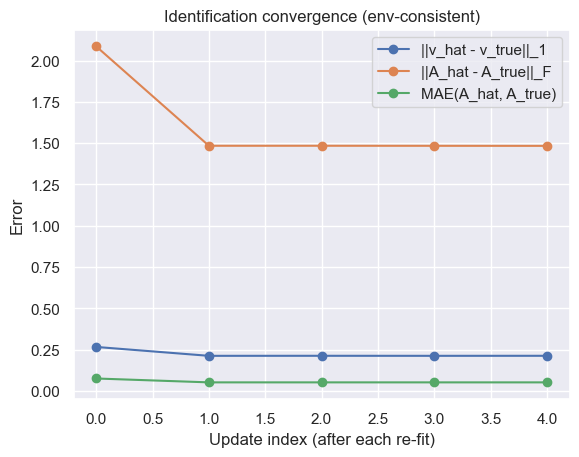

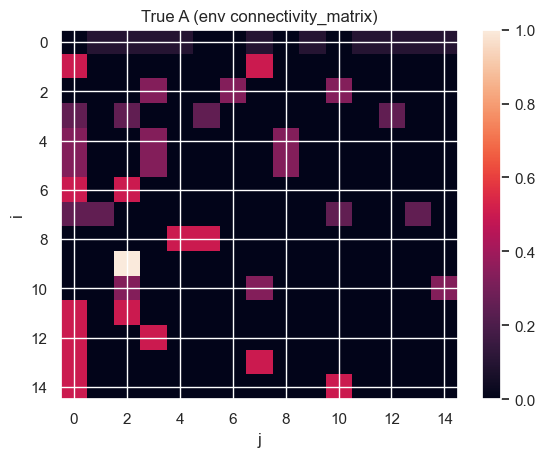

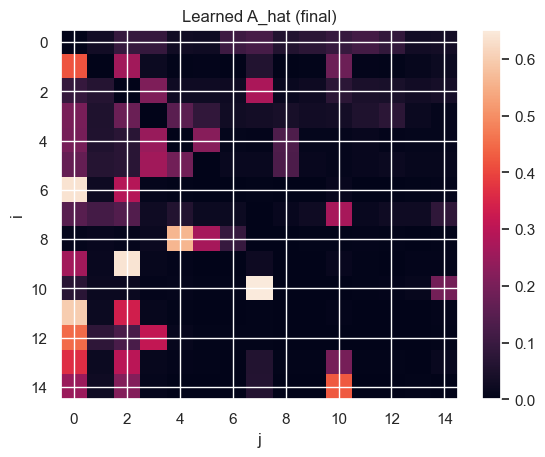

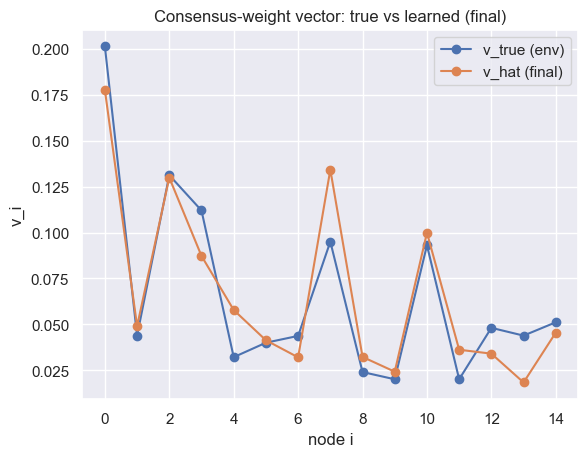

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from rl_envs_forge.envs.network_graph.graph_utils import compute_laplacian, compute_eigenvector_centrality

# --- ground truth from env (NO normalization) ---
A_true = np.asarray(out["env"].connectivity_matrix, dtype=float)
v_true = compute_eigenvector_centrality(compute_laplacian(A_true))

A_hats = out["A_hats"]

v_l1, A_fro, A_mae = [], [], []

for A_hat in A_hats:
    L_hat = compute_laplacian(A_hat)
    v_hat = v_from_P(L_hat, env.t_s)
    v_l1.append(np.abs(v_hat - v_true).sum())
    A_fro.append(np.linalg.norm(A_hat - A_true, ord="fro"))
    A_mae.append(np.mean(np.abs(A_hat - A_true)))

v_l1 = np.array(v_l1)
A_fro = np.array(A_fro)
A_mae = np.array(A_mae)

# --- Text output for debugging / sharing ---
print("=== Identification metrics (per refit) ===")
print(f"num_updates: {len(A_hats)}")

# per-update lines
for k in range(len(A_hats)):
    print(
        f"[k={k:02d}] "
        f"v_L1={v_l1[k]:.6g} | "
        f"A_Fro={A_fro[k]:.6g} | "
        f"A_MAE={A_mae[k]:.6g}"
    )

# summaries
print("\n=== Summary ===")
print("v_L1:  start/end/min =", f"{v_l1[0]:.6g}", f"{v_l1[-1]:.6g}", f"{v_l1.min():.6g}")
print("A_Fro: start/end/min =", f"{A_fro[0]:.6g}", f"{A_fro[-1]:.6g}", f"{A_fro.min():.6g}")
print("A_MAE: start/end/min =", f"{A_mae[0]:.6g}", f"{A_mae[-1]:.6g}", f"{A_mae.min():.6g}")

# true vs final v details
v_hat_final = compute_eigenvector_centrality(compute_laplacian(A_hats[-1]))
print("\n=== v details (true vs final) ===")
print("v_true sum/min/max:", f"{v_true.sum():.6g}", f"{v_true.min():.6g}", f"{v_true.max():.6g}")
print("v_hat  sum/min/max:", f"{v_hat_final.sum():.6g}", f"{v_hat_final.min():.6g}", f"{v_hat_final.max():.6g}")
print("||v_hat_final - v_true||_1:", f"{np.abs(v_hat_final - v_true).sum():.6g}")

# top-k nodes by v (often reveals sink SCC / concentration)
K = min(5, len(v_true))
top_true = np.argsort(v_true)[-K:][::-1]
top_hat  = np.argsort(v_hat_final)[-K:][::-1]
print("\nTop nodes by v_true:", [(int(i), float(v_true[i])) for i in top_true])
print("Top nodes by v_hat :", [(int(i), float(v_hat_final[i])) for i in top_hat])

# A sanity: row-stochastic and diagonal (true and learned-final)
A_true_rs = A_true.sum(axis=1)
A_hat_rs  = A_hats[-1].sum(axis=1)
print("\n=== A sanity (true vs final) ===")
print("A_true row sums min/mean/max:", f"{A_true_rs.min():.6g}", f"{A_true_rs.mean():.6g}", f"{A_true_rs.max():.6g}")
print("A_hat  row sums min/mean/max:", f"{A_hat_rs.min():.6g}", f"{A_hat_rs.mean():.6g}", f"{A_hat_rs.max():.6g}")
print("diag max abs (true, hat):", f"{np.max(np.abs(np.diag(A_true))):.6g}", f"{np.max(np.abs(np.diag(A_hats[-1]))):.6g}")

# Optional: how far A_hat is from being row-stochastic (should be ~0 if softmax-rowwise)
print("row-sum deviation (final) L_inf:", f"{np.max(np.abs(A_hat_rs - 1.0)):.6g}")

# --- Plot 1: convergence curves ---
plt.figure()
plt.plot(v_l1, marker="o", label="||v_hat - v_true||_1")
plt.plot(A_fro, marker="o", label="||A_hat - A_true||_F")
plt.plot(A_mae, marker="o", label="MAE(A_hat, A_true)")
plt.xlabel("Update index (after each re-fit)")
plt.ylabel("Error")
plt.title("Identification convergence (env-consistent)")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 2: heatmaps of true vs learned (final) ---
A_hat_final = A_hats[-1]

plt.figure()
plt.imshow(A_true, aspect="auto")
plt.title("True A (env connectivity_matrix)")
plt.colorbar()
plt.xlabel("j")
plt.ylabel("i")
plt.show()

plt.figure()
plt.imshow(A_hat_final, aspect="auto")
plt.title("Learned A_hat (final)")
plt.colorbar()
plt.xlabel("j")
plt.ylabel("i")
plt.show()

# --- Plot 3: v vectors ---
v_hat_final = compute_eigenvector_centrality(compute_laplacian(A_hat_final))

plt.figure()
plt.plot(v_true, marker="o", label="v_true (env)")
plt.plot(v_hat_final, marker="o", label="v_hat (final)")
plt.xlabel("node i")
plt.ylabel("v_i")
plt.title("Consensus-weight vector: true vs learned (final)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import numpy as np
from scipy.linalg import expm

def left_stationary_vec(P, tol=1e-12):
    # left eigenvector of P with eigenvalue 1
    w, VL = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(w - 1.0))
    v = np.real(VL[:, idx])
    v = np.maximum(v, 0)
    s = v.sum()
    return v / s if s > tol else np.ones(len(v))/len(v)

A_true = out["env"].connectivity_matrix.astype(float)
L_true = compute_laplacian(A_true)
P_true = expm(-L_true * out["env"].t_campaign)

v_true_P = v_from_P(compute_laplacian(A_true), env.t_s)
v_hat_P  = v_from_P(compute_laplacian(A_hat),  env.t_s)

A_hat = out["A_hats"][-1]
L_hat = compute_laplacian(A_hat)
P_hat = expm(-L_hat * out["env"].t_campaign)


print("||v_hat(L)-v_true(L)||_1:", np.abs(
    compute_eigenvector_centrality(L_hat) - compute_eigenvector_centrality(L_true)
).sum())

print("||v_hat(P)-v_true(P)||_1:", np.abs(v_hat_P - v_true_P).sum())

||v_hat(L)-v_true(L)||_1: 0.21309458752224344
||v_hat(P)-v_true(P)||_1: 0.21309467134119098
